In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

import seaborn as sns

DATASET_DIR = Path("../urban_sound_dataset_split")
METADATA_PATH = DATASET_DIR / "clips_metadata_with_splits.csv"

df = pd.read_csv(METADATA_PATH)

print(df.head())
print("Total clips:", len(df))
print(df["split"].value_counts())
print(df["label"].value_counts())

              clip_filename                            relative_path  \
0  bs_ozyegin16_clip025.wav     bird_sounds\bs_ozyegin16_clip025.wav   
1    pt_plane01_clip007.wav  public_transport\pt_plane01_clip007.wav   
2    pt_plane02_clip005.wav  public_transport\pt_plane02_clip005.wav   
3     ft_koru09_clip003.wav          footsteps\ft_koru09_clip003.wav   
4      pt_bus01_clip034.WAV    public_transport\pt_bus01_clip034.WAV   

              label  duration_sec            device  split  
0       bird_sounds           NaN  Zoom H4essential  train  
1  public_transport           2.0  Zoom H4essential  train  
2  public_transport           2.0  Zoom H4essential  train  
3         footsteps           NaN  Zoom H4essential  train  
4  public_transport           NaN  Zoom H4essential  train  
Total clips: 1219
split
train    853
val      183
test     183
Name: count, dtype: int64
label
bird_sounds         175
public_transport    150
footsteps           150
traffic             150
siren     

In [3]:
TARGET_SR = 16000
TARGET_DURATION = 2.0
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

def load_audio_fixed(path, target_sr=TARGET_SR, target_length=TARGET_LENGTH):
    y, sr = librosa.load(path, sr=target_sr, mono=True)

    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode="constant")
    else:
        y = y[:target_length]

    return y, target_sr

In [4]:
def extract_mfcc_features(path, n_mfcc=40):
    y, sr = load_audio_fixed(path)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=256
    )

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    features = np.concatenate([mfcc_mean, mfcc_std])
    return features

In [5]:
X = []
y = []

for idx, row in df.iterrows():
    file_path = DATASET_DIR / row["split"] / row["label"] / row["clip_filename"]

    features = extract_mfcc_features(file_path)
    X.append(features)
    y.append(row["label"])

    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(df)} clips")

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Processed 100/1219 clips
Processed 200/1219 clips
Processed 300/1219 clips
Processed 400/1219 clips
Processed 500/1219 clips
Processed 600/1219 clips
Processed 700/1219 clips
Processed 800/1219 clips
Processed 900/1219 clips
Processed 1000/1219 clips
Processed 1100/1219 clips
Processed 1200/1219 clips
X shape: (1219, 80)
y shape: (1219,)


In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, cls)

train_mask = df["split"] == "train"
val_mask = df["split"] == "val"
test_mask = df["split"] == "test"

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y_encoded[train_mask]
y_val = y_encoded[val_mask]
y_test = y_encoded[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Classes:
0 bird_sounds
1 construction
2 crowd_chatter
3 footsteps
4 public_transport
5 siren
6 traffic
7 wind_trees
Train: (853, 80) (853,)
Val: (183, 80) (183,)
Test: (183, 80) (183,)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    batch_size=32,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
    verbose=True
)

mlp.fit(X_train_scaled, y_train)

Iteration 1, loss = 1.59266075
Validation score: 0.726562
Iteration 2, loss = 0.80596188
Validation score: 0.828125
Iteration 3, loss = 0.50784888
Validation score: 0.859375
Iteration 4, loss = 0.35624442
Validation score: 0.914062
Iteration 5, loss = 0.26748707
Validation score: 0.890625
Iteration 6, loss = 0.20594013
Validation score: 0.875000
Iteration 7, loss = 0.16980025
Validation score: 0.890625
Iteration 8, loss = 0.15102105
Validation score: 0.867188
Iteration 9, loss = 0.12527015
Validation score: 0.859375
Iteration 10, loss = 0.10943778
Validation score: 0.859375
Iteration 11, loss = 0.10072355
Validation score: 0.875000
Iteration 12, loss = 0.09979488
Validation score: 0.859375
Iteration 13, loss = 0.07882038
Validation score: 0.851562
Iteration 14, loss = 0.07970135
Validation score: 0.851562
Iteration 15, loss = 0.07640698
Validation score: 0.882812
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [9]:
val_pred = mlp.predict(X_val_scaled)

val_acc = accuracy_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred, average="macro")

print("Validation Accuracy:", val_acc)
print("Validation Macro-F1:", val_f1)

print(classification_report(
    y_val,
    val_pred,
    target_names=label_encoder.classes_
))

Validation Accuracy: 0.8907103825136612
Validation Macro-F1: 0.8864930067425115
                  precision    recall  f1-score   support

     bird_sounds       1.00      0.96      0.98        27
    construction       0.74      1.00      0.85        23
   crowd_chatter       0.96      1.00      0.98        22
       footsteps       0.74      0.77      0.76        22
public_transport       0.88      0.95      0.91        22
           siren       1.00      0.96      0.98        23
         traffic       0.95      0.82      0.88        22
      wind_trees       0.93      0.64      0.76        22

        accuracy                           0.89       183
       macro avg       0.90      0.89      0.89       183
    weighted avg       0.90      0.89      0.89       183



In [10]:
test_pred = mlp.predict(X_test_scaled)

test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="macro")

print("Test Accuracy:", test_acc)
print("Test Macro-F1:", test_f1)

print(classification_report(
    y_test,
    test_pred,
    target_names=label_encoder.classes_
))

Test Accuracy: 0.9180327868852459
Test Macro-F1: 0.9108071671236565
                  precision    recall  f1-score   support

     bird_sounds       1.00      1.00      1.00        26
    construction       0.85      1.00      0.92        22
   crowd_chatter       0.96      1.00      0.98        23
       footsteps       0.76      0.96      0.85        23
public_transport       0.92      1.00      0.96        23
           siren       0.95      0.95      0.95        22
         traffic       1.00      0.83      0.90        23
      wind_trees       1.00      0.57      0.73        21

        accuracy                           0.92       183
       macro avg       0.93      0.91      0.91       183
    weighted avg       0.93      0.92      0.91       183



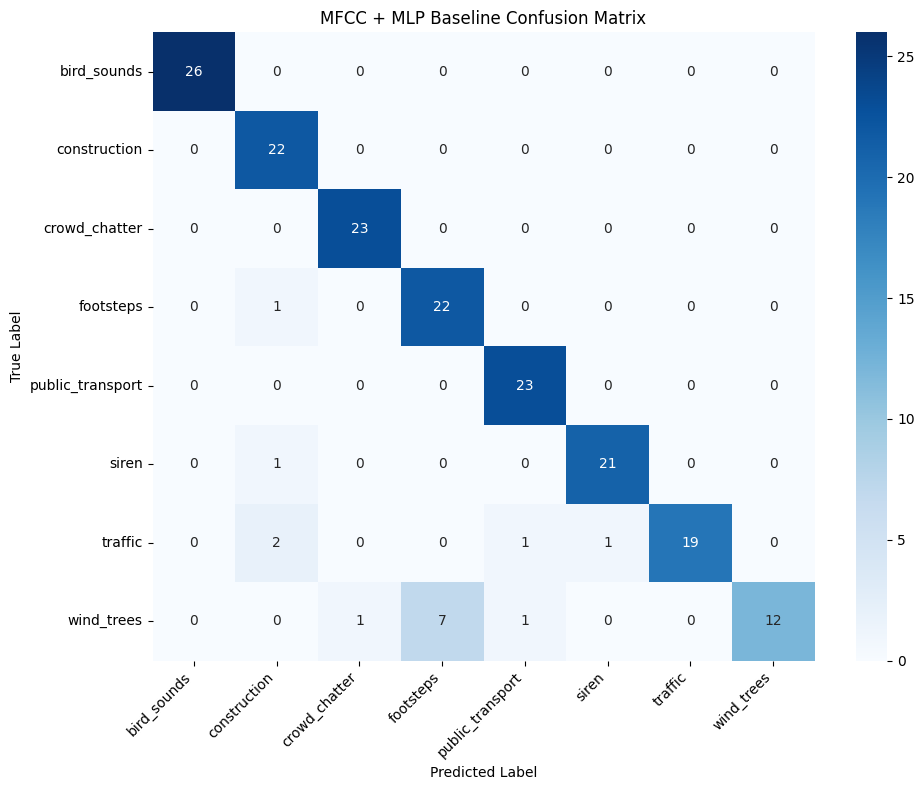

In [11]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("MFCC + MLP Baseline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

baseline_results = {
    "model": "MFCC + MLP",
    "features": "40 MFCC mean + std",
    "validation_accuracy": val_acc,
    "validation_macro_f1": val_f1,
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1,
    "hidden_layers": "(128, 64)",
    "learning_rate": 1e-3,
    "batch_size": 32
}

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv(RESULTS_DIR / "mfcc_mlp_baseline_results.csv", index=False)

baseline_df

,model,features,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,hidden_layers,learning_rate,batch_size
0,MFCC + MLP,40 MFCC mean + std,0.89071,0.886493,0.918033,0.910807,"(128, 64)",0.001,32
